In [1]:
import yaml
import torch
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt

from pud.collector import Collector
from pud.vision_agent import VisionUVFDDPG
from pud.visualize import plot_agent_paths
from pud.utils import set_global_seed, set_env_seed
from pud.algos.constrained_collector import ConstrainedCollector
from pud.policies import VisualSearchPolicy, VisualMultiAgentSearchPolicy
from pud.envs.safe_pointenv.pb_sampler import load_pb_set, sample_pbs_by_agent
from pud.envs.habitat_navigation_env import GoalConditionedHabitatPointWrapper, habitat_env_load_fn
from pud.envs.safe_habitatenv.safe_habitat_wrappers import SafeGoalConditionedHabitatPointWrapper, SafeGoalConditionedHabitatPointQueueWrapper

#### Load the evaluation configuration

In [2]:
illustration_pb_file = "pud/envs/safe_habitatenv/illustration_set/SC1_staging.txt"
unconstrained_ckpt_file = "runs_debug/hatbitat/job_26461272_venv=1/2024-07-07-02-59-36/ckpt/ckpt_1965000"
config_file = "runs_debug/hatbitat/job_26461272_venv=1/2024-07-07-02-59-36/bk/config.yaml"
constrained_ckpt_file = ""

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [3]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "GoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(GoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = habitat_env_load_fn(
    **config.env.toDict(),
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=(GoalConditionedHabitatPointWrapper,),  # type: ignore
    wrapper_kwargs=gym_env_wrapper_kwargs,
    device=config.device,
    terminate_on_timeout=True,
)
set_env_seed(eval_env, config.seed + 2)

Renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 550.90.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
[INFO] loading prior apsp pickle: pud/envs/safe_habi

[14:54:54:376600]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[14:54:54:376618]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[14:54:54:376623]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[14:54:54:376628]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_03.navmesh` not found on disk as absolute path or relativ

#### Load the inference agent

In [4]:
config.agent["action_dim"] = eval_env.action_space.shape[0]  # type: ignore
config.agent["max_action"] = float(eval_env.action_space.high[0])  # type: ignore

agent = VisionUVFDDPG(
    width=config.env.simulator_settings.width,
    height=config.env.simulator_settings.height,
    in_channels=4,
    act_fn=torch.nn.SELU,
    encoder="VisualEncoder",
    device=config.device,
    **config.agent.toDict(),
)

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

VisionUVFDDPG(
  (actor): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l1): Linear(in_features=512, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l1):

#### Sample a replay buffer to form our search graph

In [5]:
rb_vec_grid, rb_vec_visual = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size, habitat=True)
pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore

#### Sample (start, goal) problems for the agent

## Single-Agent Comparisons

### Unconstrained Low-Level Policy

In [6]:
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
start, goal, unconstrained_observations, _, _ = Collector.get_trajectory(agent, eval_env, habitat=True)

### Unconstrained Low-Level Policy with Graph Search

In [7]:
eval_env.duration = 300  # type: ignore

search_policy = VisualSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), pdist=pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True,)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _ = Collector.get_trajectory(search_policy, eval_env, habitat=True, input_start=start, input_goal=goal)

/home/mers-pluto/Desktop/Work/Multi_Agent_Research/Hierarchical_Constrained_SORB/cc-sorb-rev/pud/vision_agent.py:325: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1712608883701/work/torch/csrc/utils/tensor_new.cpp:274.)
  observation=torch.FloatTensor(state['observation']),


### Constrained Low-Level Policy

### Constrained Low-Level Policy with Graph Search

#### Plot the single-agent comparison

In [8]:
height, width = eval_env.walls.shape
normalization_factor = np.array([height, width])

start = start[0] / normalization_factor
goal = goal[0] / normalization_factor

unconstrained_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_observations])
unconstrained_search_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations])
unconstrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


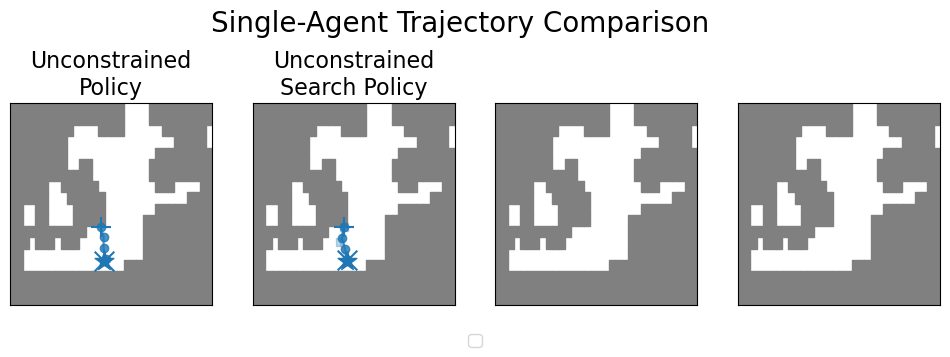

In [9]:
from pud.envs.habitat_navigation_env import plot_wall


fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax in axs:
    ax = plot_wall(eval_env.walls, ax)
    # ax.imshow(1.0 - eval_env.walls, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

axs[0] = plot_agent_paths(0, start, goal, unconstrained_observations, "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs[1] = plot_agent_paths(0, start, goal, unconstrained_search_observations, "Unconstrained\nSearch Policy", axs[1], wps=unconstrained_search_waypoints, use_agent_id=False)

plt.legend(loc="lower center", bbox_to_anchor=(-1.3, -0.25), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=20)

## Multi-Agent Comparisons

### Unconstrained Low-Level Policy

In [10]:
n_agents = 4
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
start, goal, unconstrained_observations, _, _ = Collector.get_trajectories(agent, eval_env, n_agents, habitat=True)

Sampled the required starts and goals


### Unconstrained Low-Level Policy with Graph Search

In [11]:
eval_env.duration = 300  # type: ignore

ma_search_policy = VisualMultiAgentSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), n_agents, pdist=pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _ = Collector.get_trajectories(ma_search_policy, eval_env, n_agents, habitat=True, input_starts=start, input_goals=goal)

Composite starts:  [array([18.39145836, 14.39358275]), array([3.64693514, 5.88536171]), array([2.96341495, 3.98813718]), array([13.73423468, 12.49827638])]
Composite goals:  [array([22.67258669, 14.87206632]), array([5.73051734, 3.34885307]), array([4.02755298, 4.41569412]), array([14.84979271, 14.9908437 ])]
Initial graph size =  1000
Final graph size =  1008
Finding paths using CBS Solver
[]
Generated:  0
Expanded:  0
Printing the paths
--------------------
Path for agent  0
Start:  [18.39145836 14.39358275]
Vertex:  [19.20174323 15.64040673]
Vertex:  [20.50753546 15.97955995]
Goal:  [22.67258669 14.87206632]
--------------------
Path for agent  1
Start:  [3.64693514 5.88536171]
Vertex:  [3.09630412 5.82004169]
Vertex:  [4.52075223 4.53906511]
Goal:  [5.73051734 3.34885307]
--------------------
Path for agent  2
Start:  [2.96341495 3.98813718]
Vertex:  [3.02638415 4.86970863]
Goal:  [4.02755298 4.41569412]
--------------------
Path for agent  3
Start:  [13.73423468 12.49827638]
Verte

### Constrained Low-Level Policy

### Constrained Low-Level Policy with Graph Search

#### Plot the multi-agent comparison

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


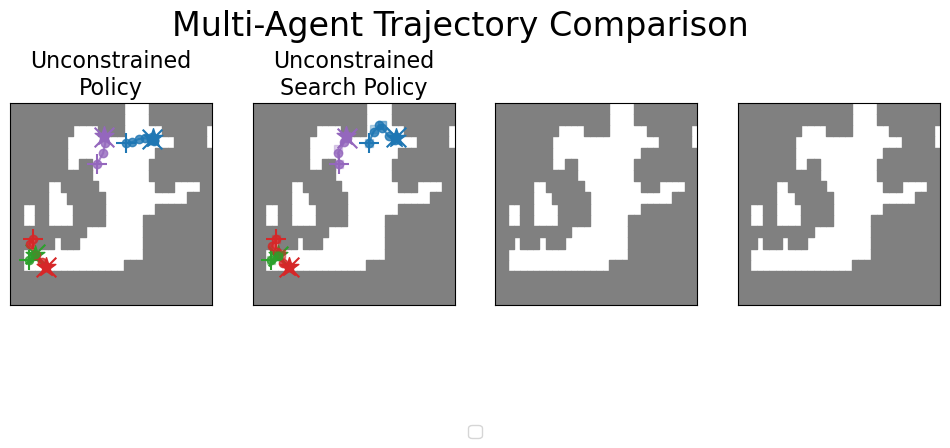

In [12]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax in axs:
    ax = plot_wall(eval_env.walls, ax)
    ax.set_xticks([])
    ax.set_yticks([])

for agent_id in range(n_agents):

    agent_start = start[agent_id][0] / normalization_factor
    agent_goal = goal[agent_id][0] / normalization_factor

    agent_unconstrained_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_observations[agent_id]])
    agent_unconstrained_search_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations[agent_id]])
    agent_unconstrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints[agent_id]])

    axs[0] = plot_agent_paths(agent_id, agent_start, agent_goal, agent_unconstrained_observations, "Unconstrained\nPolicy", axs[0])
    axs[1] = plot_agent_paths(agent_id, agent_start, agent_goal, agent_unconstrained_search_observations, "Unconstrained\nSearch Policy", axs[1], wps=agent_unconstrained_search_waypoints)

plt.legend(loc="lower center", bbox_to_anchor=(-1.3, -0.7), ncol=4, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)